In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN


# Task 1: Data Loading and Exploratory Data Analysis

Objective: Load and explore the Mall Customers dataset and understand its structure, distributions, and relationships.

Expected: Clean dataset information, feature distributions, pairplot, and correlation heatmap.

In [4]:

# 1.1 Load Dataset
df = pd.read_csv("Mall_Customers.csv")

print("First 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000



Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
# 1.2 Rename and drop columns

# Rename columns
df = df.rename(columns={
    "Annual Income (k$)": "Annual_Income",
    "Spending Score (1-100)": "Spending_Score"
})

# Drop CustomerID
df = df.drop(columns=["CustomerID"])

# Check updated columns
print("Columns after renaming and dropping:")
print(df.columns)

# Display first 5 rows
display(df.head())

Columns after renaming and dropping:
Index(['Gender', 'Age', 'Annual_Income', 'Spending_Score'], dtype='object')


,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [6]:
# 1.3 Encode Gender

# Create LabelEncoder
le = LabelEncoder()

# Encode Gender
df["Gender"] = le.fit_transform(df["Gender"])

# Check result
display(df.head())

,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


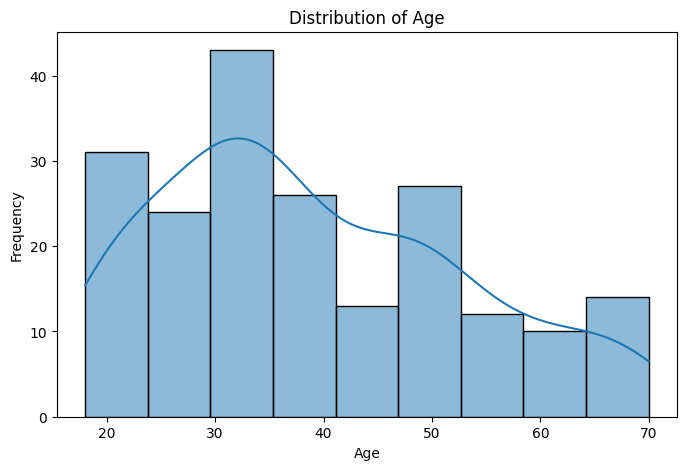

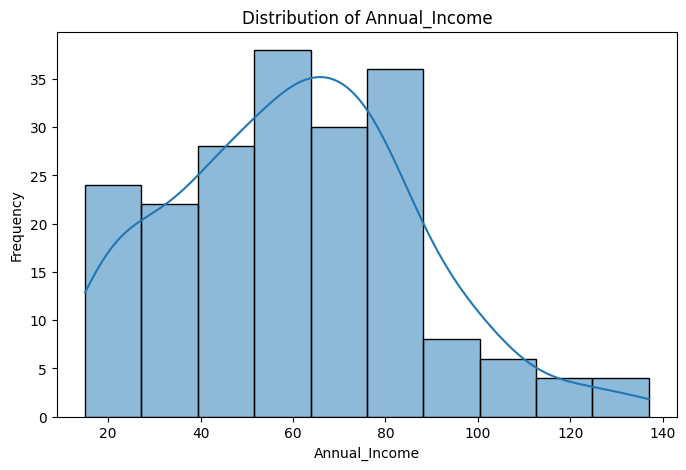

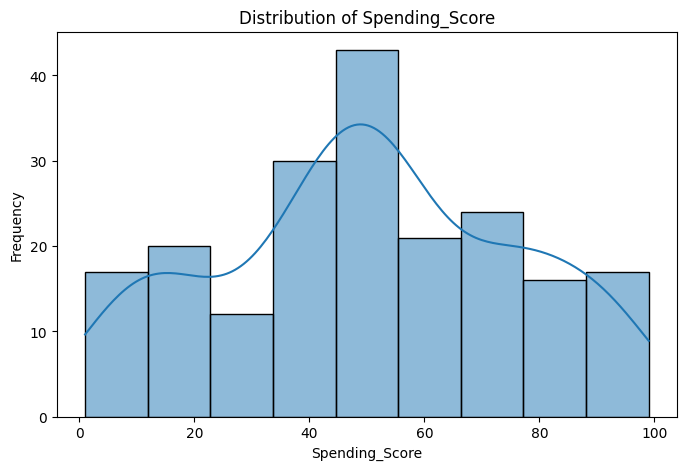

In [7]:
# 1.4 Univariate Distributions

features = ["Age", "Annual_Income", "Spending_Score"]

for feature in features:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(df[feature], kde=True)
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    
    plt.show()


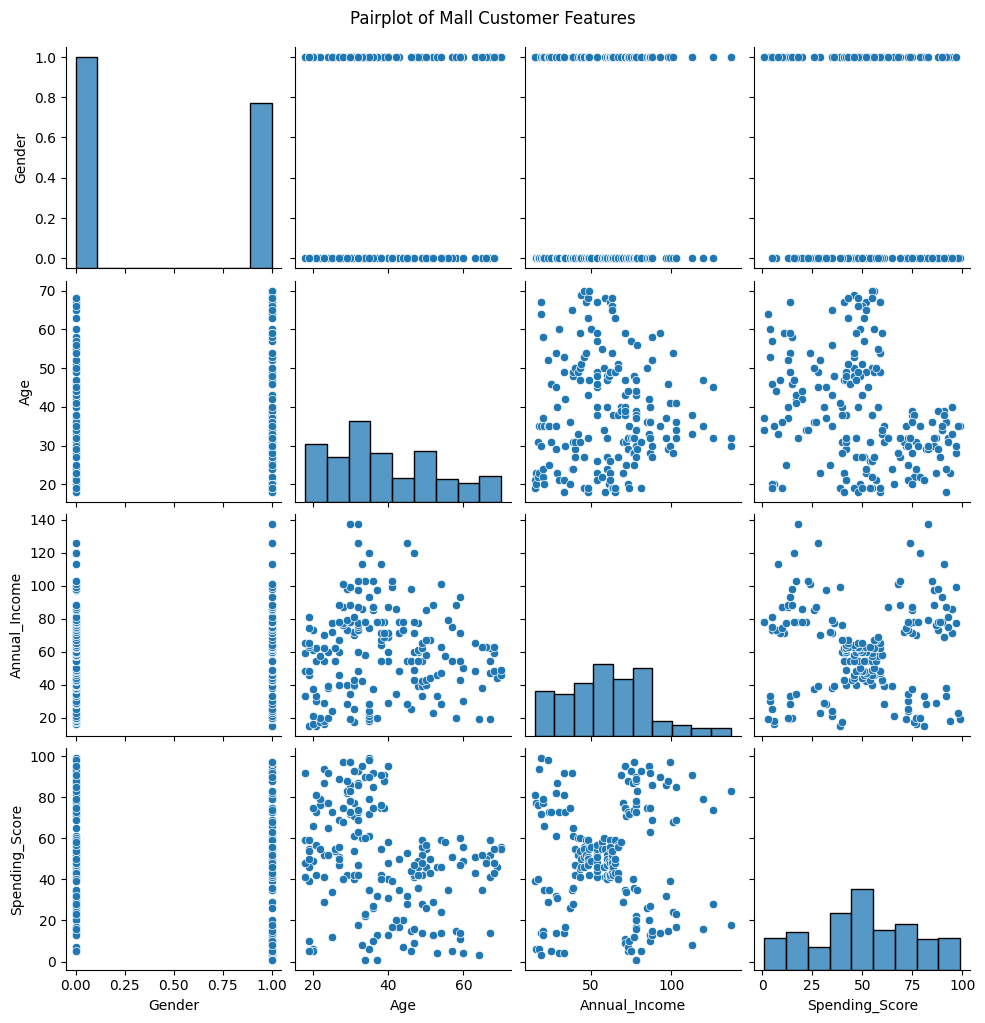

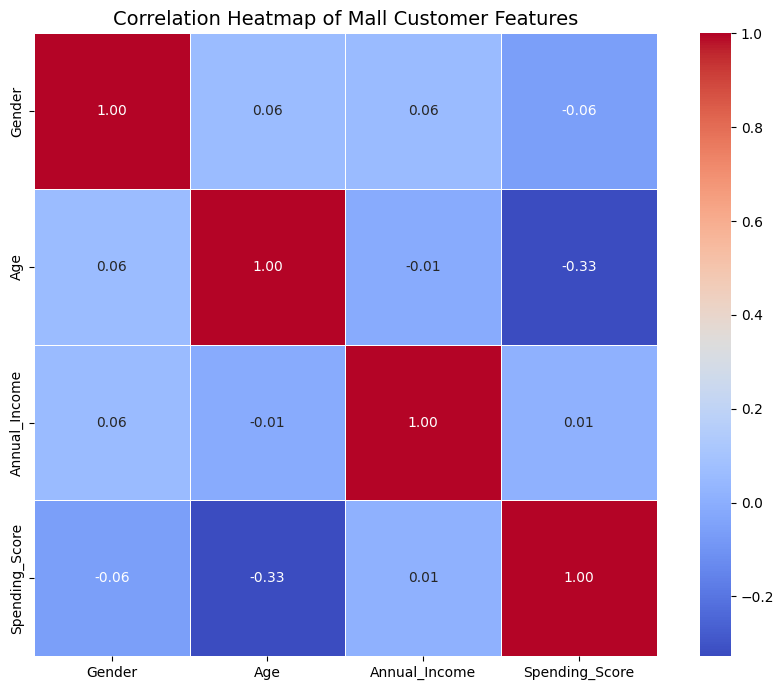

In [8]:
# 1.5 Pairplot & correlation heatmap

# Create pairplot
sns.pairplot(
    df,
    hue=None,
    diag_kind="hist"
)

plt.suptitle("Pairplot of Mall Customer Features", y=1.02)

plt.show()


# Correlation Heatmap

# Calculate correlation matrix
correlation_matrix = df.corr()

# Create figure
plt.figure(figsize=(9, 7))

# Create heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

# Add title
plt.title("Correlation Heatmap of Mall Customer Features", fontsize=14)

plt.tight_layout()
plt.show()

## 1.6 EDA Summary

- The pairplot shows that customers have different patterns based on Age, Annual Income, and Spending Score, with some visible separation between groups.

- The correlation heatmap shows that most features do not have very strong linear correlations with each other.

- Age and Spending Score do not show a strong linear relationship, indicating that age alone may not clearly separate customer groups.

- Annual Income and Spending Score are selected as the main features for customer segmentation because their scatter plot provides clearer visual separation between different customer groups.

- Therefore, Annual Income and Spending Score will be used as the primary two-feature subset for clustering and visualization.

# Task 2: Data Preprocessing

Objective: Prepare the customer data for clustering by encoding categorical data and standardising numerical features.

Expected: Scaled numerical features and the two-feature dataset containing Annual_Income and Spending_Score.

In [9]:

# 2.1 Feature Scaling

# Select numerical features to scale
features = ["Age", "Annual_Income", "Spending_Score"]

# Create StandardScaler object
scaler = StandardScaler()

# Fit and transform selected features
scaled_values = scaler.fit_transform(df[features])

# Store scaled values in a new DataFrame
df_scaled = pd.DataFrame(
    scaled_values,
    columns=features,
    index=df.index
)

# Display first 5 rows
display(df_scaled.head())

,Age,Annual_Income,Spending_Score
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [10]:
#2.2: Select 2-Feature Subset

# Select Annual_Income and Spending_Score from scaled data
df_2f = df_scaled[["Annual_Income", "Spending_Score"]].copy()

# Display first 5 rows
print("First 5 rows of df_2f:")
display(df_2f.head())

# Check selected columns
print("\nSelected columns:")
print(df_2f.columns.tolist())

# Check shape
print("\nShape of df_2f:")
print(df_2f.shape)

# Check data types
print("\nData types:")
print(df_2f.dtypes)

# Check for missing values
print("\nMissing values:")
print(df_2f.isnull().sum())



First 5 rows of df_2f:


,Annual_Income,Spending_Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980



Selected columns:
['Annual_Income', 'Spending_Score']

Shape of df_2f:
(200, 2)

Data types:
Annual_Income     float64
Spending_Score    float64
dtype: object

Missing values:
Annual_Income     0
Spending_Score    0
dtype: int64


## 2.2 Select 2-Feature Subset

The primary clustering tasks use the two features `Annual_Income` and
`Spending_Score` from the scaled dataset.

These features are stored in a new DataFrame called `df_2f`.

The two-feature subset is selected because it provides clear visual
separation between customer groups and allows direct 2D scatter
visualisation without using PCA.

Using all four features is also valid and will be tested in Task 6
(Extension). However, the primary clustering tasks use `df_2f` for
better visual clarity.

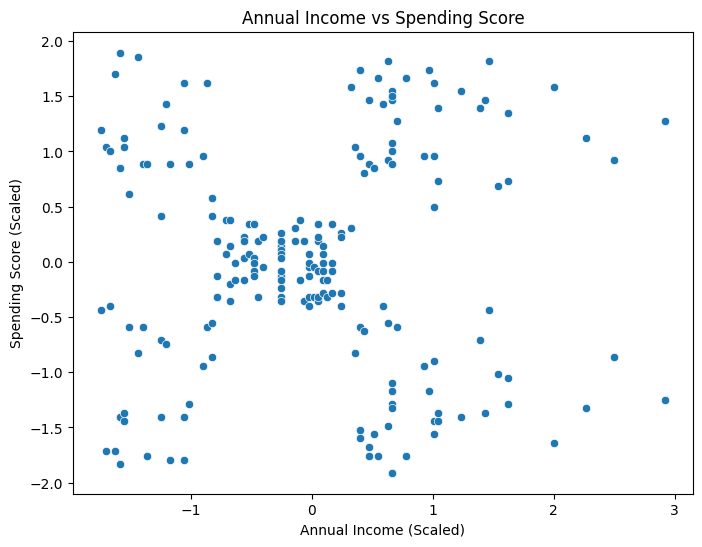

In [11]:
# Visualize the selected 2 features

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_2f,
    x="Annual_Income",
    y="Spending_Score"
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")

plt.show()

## 2.3 Why StandardScaler is Applied Before Clustering?

StandardScaler is applied before clustering because distance-based
clustering algorithms such as K-Means and DBSCAN are sensitive to the
magnitude and scale of features.

In the Mall Customers dataset, the raw ranges of the features are
different. For example, Annual_Income ranges approximately from 15 to
137, while Spending_Score ranges from 1 to 100.

Without scaling, features with larger numerical ranges can have a
greater influence on distance calculations. This can cause the clustering
algorithm to give more importance to Annual_Income and produce biased
customer groups.

StandardScaler transforms the numerical features to a comparable scale
with a mean close to 0 and a standard deviation close to 1.

Therefore, scaling allows K-Means and DBSCAN to calculate distances more
fairly and helps produce more meaningful customer clusters.

# Task 3: K-Means Clustering

Objective: Determine a suitable number of clusters and perform K-Means customer segmentation.

Expected: Elbow plot, Silhouette Score plot, and scatter plot with labelled K-Means clusters.

Inertia values:
k = 1: Inertia = 400.00
k = 2: Inertia = 269.69
k = 3: Inertia = 157.70
k = 4: Inertia = 108.92
k = 5: Inertia = 65.57
k = 6: Inertia = 55.06
k = 7: Inertia = 44.86
k = 8: Inertia = 37.23
k = 9: Inertia = 32.39
k = 10: Inertia = 29.98


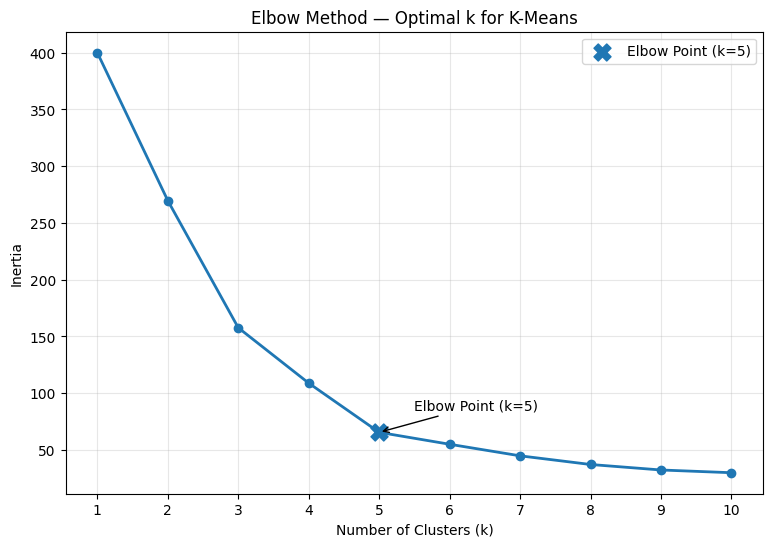

In [12]:

# 3.1 Elbow Method

# Store inertia values
inertias = []

# Test K values from 1 to 10
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(df_2f)
    
    # Store inertia
    inertias.append(kmeans.inertia_)

# Display inertia values
print("Inertia values:")
for k, inertia in zip(k_values, inertias):
    print(f"k = {k}: Inertia = {inertia:.2f}")


# Plot Elbow Curve


plt.figure(figsize=(9, 6))

plt.plot(
    k_values,
    inertias,
    marker="o",
    linewidth=2
)

# Mark the elbow point
elbow_k = 5

plt.scatter(
    elbow_k,
    inertias[elbow_k - 1],
    s=150,
    marker="X",
    label=f"Elbow Point (k={elbow_k})"
)

plt.annotate(
    f"Elbow Point (k={elbow_k})",
    xy=(elbow_k, inertias[elbow_k - 1]),
    xytext=(elbow_k + 0.5, inertias[elbow_k - 1] + 20),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Elbow Method — Optimal k for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

## 3.1 Elbow Method

The Elbow Method is used to determine a suitable number of clusters
for K-Means clustering.

Inertia, also called Within-Cluster Sum of Squares (WCSS), measures
the total squared distance between each data point and the centroid
of its assigned cluster.

A lower inertia means that the data points are closer to their cluster
centroids. As the number of clusters increases, inertia decreases
because the data is divided into more groups.

However, after a certain number of clusters, the reduction in inertia
becomes much smaller. This point creates a bend or "elbow" in the
curve and represents a reasonable choice for k.

For this dataset, the elbow is around k = 5, which will be used as
the initial number of clusters for K-Means.




Silhouette Scores:
k = 2: Silhouette Score = 0.3213
k = 3: Silhouette Score = 0.4666
k = 4: Silhouette Score = 0.4939
k = 5: Silhouette Score = 0.5547
k = 6: Silhouette Score = 0.5399
k = 7: Silhouette Score = 0.5281
k = 8: Silhouette Score = 0.4552
k = 9: Silhouette Score = 0.4571
k = 10: Silhouette Score = 0.4432

Best k based on Silhouette Score: 5
Highest Silhouette Score: 0.5547


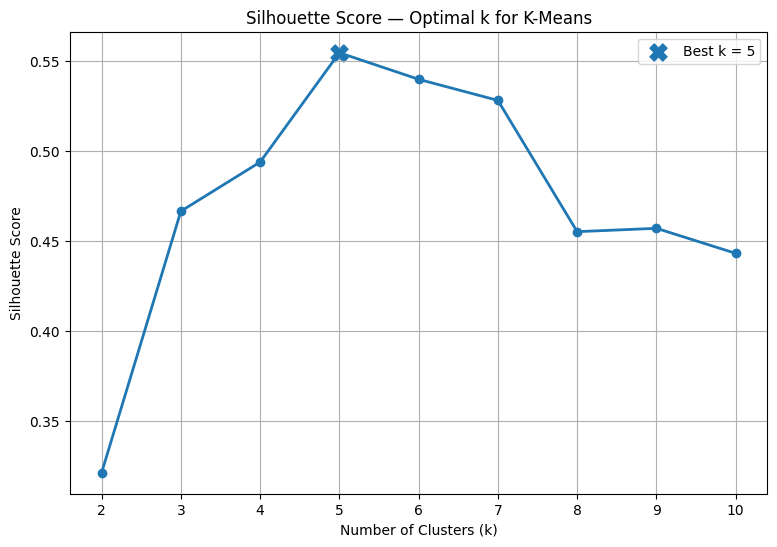

In [13]:
# 3.2 Silhouette Score

silhouette_scores = []

# Calculate silhouette score for k = 2 to 10
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(df_2f)
    
    score = silhouette_score(df_2f, labels)
    silhouette_scores.append(score)

# Print silhouette scores
print("Silhouette Scores:")

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k = {k}: Silhouette Score = {score:.4f}")

# Find the k with highest silhouette score
best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]
best_score = max(silhouette_scores)

print("\nBest k based on Silhouette Score:", best_k)
print("Highest Silhouette Score:", round(best_score, 4))

# Plot silhouette scores
plt.figure(figsize=(9, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o",
    linewidth=2
)

# Mark the best k
plt.scatter(
    best_k,
    best_score,
    s=150,
    marker="X",
    label=f"Best k = {best_k}"
)

plt.title("Silhouette Score — Optimal k for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True)
plt.legend()

plt.show()

3.2 Silhouette Score

The Silhouette Score measures how well each data point fits within its assigned cluster compared with the nearest neighboring cluster.

The score ranges from -1 to 1. A higher score indicates that the clusters are more compact and better separated.

Silhouette Scores were calculated for k values from 2 to 10. The k with the highest Silhouette Score is considered the data-driven optimum.

The Silhouette Score optimum is compared with the k selected using the Elbow Method. The two methods may produce different values because they measure different aspects of clustering quality.

The Elbow Method focuses on reducing within-cluster inertia, while the Silhouette Score considers both within-cluster compactness and separation between clusters.

In [14]:
# 3.3 Fit final K-Means model


# Selected k from Elbow Method / Silhouette Score
k = 5

# Fit final K-Means model
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

# Predict cluster labels
df["KMeans_Cluster"] = kmeans.fit_predict(df_2f)

# Display results
display(df.head())

# Check cluster counts
print("Cluster Counts:")
print(df["KMeans_Cluster"].value_counts().sort_index())

,Gender,Age,Annual_Income,Spending_Score,KMeans_Cluster
0,1,19,15,39,4
1,1,21,15,81,2
2,0,20,16,6,4
3,0,23,16,77,2
4,0,31,17,40,4


Cluster Counts:
KMeans_Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


## 3.3 Fit Final K-Means Model

The final K-Means model is fitted using k = 5 clusters on the selected two features, Annual_Income and Spending_Score.

The predicted cluster labels are added to the original DataFrame as a new column named KMeans_Cluster.

Each customer is therefore assigned to one of the five clusters based on their scaled Annual Income and Spending Score.

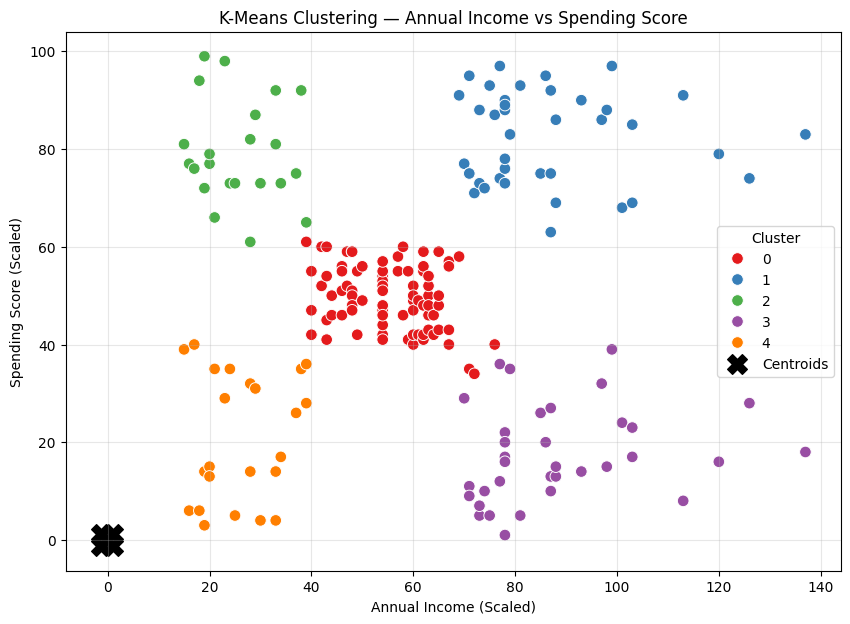

In [15]:
# 3.4 Visualise K-Means clusters

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="KMeans_Cluster",
    data=df,
    palette="Set1",
    s=70
)

# Plot cluster centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c="black",
    marker="X",
    s=200,
    label="Centroids"
)

plt.title("K-Means Clustering — Annual Income vs Spending Score")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.3)

plt.show()

## 3.4 Visualise K-Means Clusters

The K-Means clusters are visualised using Annual Income and Spending Score.

Each colour represents a different customer cluster, while the black X markers represent the cluster centroids.

The plot helps to visually understand how customers are grouped based on their Annual Income and Spending Score.

In [16]:
# 3.5 Cluster profile table


# Create cluster profile table
cluster_profile = df.groupby("KMeans_Cluster")[
    ["Age", "Annual_Income", "Spending_Score"]
].mean().round(2)

# Display as styled pandas table
cluster_profile.style \
    .set_caption("K-Means Cluster Profile") \
    .format("{:.2f}") \
    .background_gradient(cmap="Blues")

,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


In [17]:
cluster_profile = df.groupby("KMeans_Cluster")[
    ["Age", "Annual_Income", "Spending_Score"]
].mean().round(2)

cluster_profile["Customer_Count"] = df["KMeans_Cluster"].value_counts().sort_index()

cluster_profile.style \
    .set_caption("K-Means Cluster Profile") \
    .format("{:.2f}") \
    .background_gradient(cmap="Blues")

,Age,Annual_Income,Spending_Score,Customer_Count
KMeans_Cluster,,,,
0,42.72,55.30,49.52,81.00
1,32.69,86.54,82.13,39.00
2,25.27,25.73,79.36,22.00
3,41.11,88.20,17.11,35.00
4,45.22,26.30,20.91,23.00


## 3.5 Cluster Profile and Business Interpretation

The cluster profile table shows the average Age, Annual Income, and Spending Score for each customer cluster.

### Cluster 0 — Low Income, Low Spenders
These customers have relatively low annual income and low spending scores.

Business implication:
The mall can target this segment with affordable products, discounts, value deals, and promotional offers to encourage more visits and purchases.

### Cluster 1 — High Income, Low Spenders
These customers have relatively high annual income but lower spending scores.

Business implication:
The mall can use personalised offers, premium product recommendations, loyalty programs, and targeted promotions to increase their spending.

### Cluster 2 — Low Income, High Spenders
These customers have relatively lower annual income but higher spending scores.

Business implication:
The mall can retain these customers through loyalty rewards, special discounts, and attractive offers because they already show strong shopping engagement.

### Cluster 3 — High Income, High Spenders
These customers have relatively high annual income and high spending scores.

Business implication:
This segment can be targeted with premium brands, exclusive offers, VIP memberships, personalised experiences, and high-value loyalty programs.

### Cluster 4 — Moderate Income, Moderate Spenders
These customers show relatively moderate income and spending behaviour.

Business implication:
The mall can use general promotions, seasonal campaigns, cross-selling, and loyalty incentives to gradually increase their purchase frequency and spending.

Note: The exact segment names should be confirmed from the cluster profile table because K-Means cluster numbers are assigned automatically and may differ between runs.

# Task 4: Agglomerative Hierarchical Clustering

Objective: Apply hierarchical clustering and compare its customer segments with K-Means.

Expected: Dendrogram, hierarchical cluster scatter plot, and cluster profile comparison.

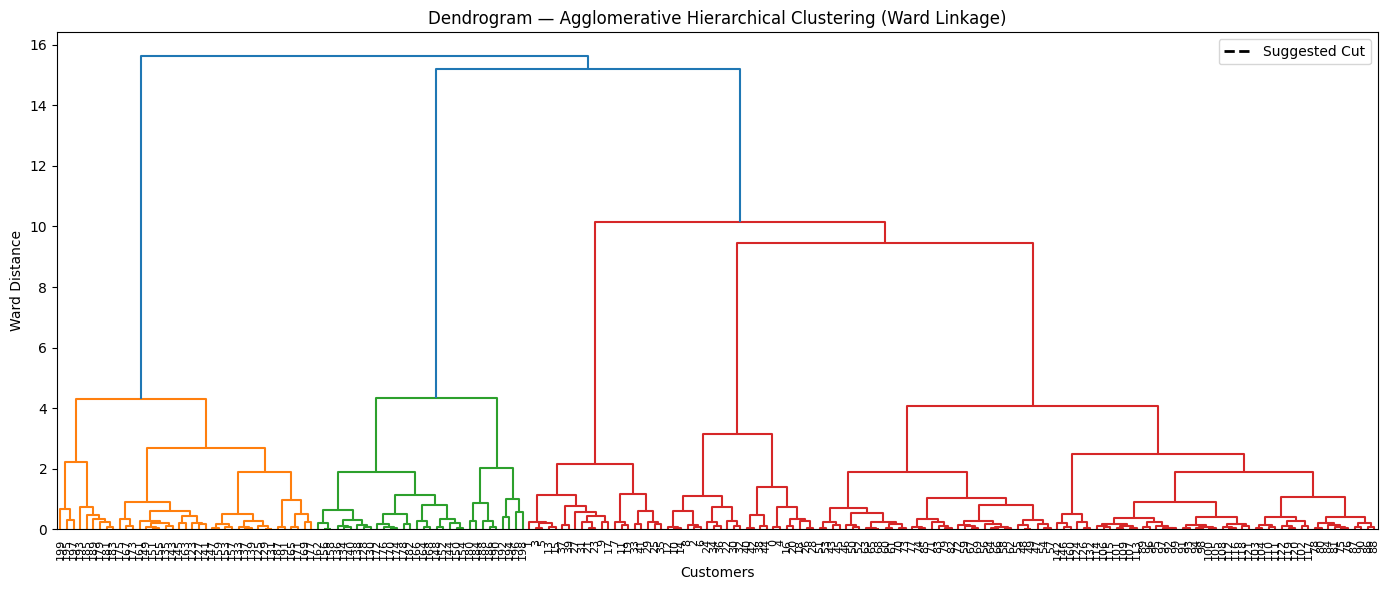

In [18]:

# 4.1 Dendrogram


# Compute hierarchical clustering using Ward linkage
Z = linkage(df_2f, method="ward")

# Plot dendrogram
plt.figure(figsize=(14, 6))

dendrogram(
    Z,
    leaf_rotation=90,
    leaf_font_size=8
)

# Horizontal dashed line to indicate the selected cut
# Adjust the value after observing the largest vertical gap
plt.axhline(
    y=200,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Suggested Cut"
)

plt.title(
    "Dendrogram — Agglomerative Hierarchical Clustering (Ward Linkage)"
)
plt.xlabel("Customers")
plt.ylabel("Ward Distance")
plt.legend()

plt.tight_layout()
plt.show()

## 4.1 Dendrogram

A dendrogram is used to visualise the process of Agglomerative Hierarchical Clustering.

Ward linkage is used because it combines clusters in a way that minimises the increase in within-cluster variance. In other words, Ward linkage tries to create compact and internally similar clusters.

To read the dendrogram, start from the bottom and follow the branches upward. Each joining point represents two clusters being merged.

The vertical height of a joining point represents the distance between the clusters being merged. A large vertical gap indicates that substantially different clusters are being combined.

A horizontal cut can be drawn through a large vertical gap. The number of vertical branches crossed by this cut gives the suggested number of clusters.

Therefore, the dendrogram helps identify a suitable number of clusters for Agglomerative Hierarchical Clustering.

In [19]:
# 4.2 Fit Agglomerative model


# Number of clusters selected from the dendrogram
n_clusters = 5

# Fit Agglomerative Hierarchical Clustering
hier_model = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage="ward"
)

# Predict cluster labels
df["Hier_Cluster"] = hier_model.fit_predict(df_2f)

# Display results
display(df.head())

# Check number of customers in each cluster
print("Hierarchical Cluster Counts:")
print(df["Hier_Cluster"].value_counts().sort_index())

,Gender,Age,Annual_Income,Spending_Score,KMeans_Cluster,Hier_Cluster
0,1,19,15,39,4,4
1,1,21,15,81,2,3
2,0,20,16,6,4,4
3,0,23,16,77,2,3
4,0,31,17,40,4,4


Hierarchical Cluster Counts:
Hier_Cluster
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64


## 4.2 Fit Agglomerative Hierarchical Clustering

The AgglomerativeClustering model is fitted using 5 clusters, based on the dendrogram analysis.

Ward linkage is used to create compact clusters by minimising the increase in within-cluster variance.

The resulting cluster labels are stored in a new column named `Hier_Cluster` in the original DataFrame.

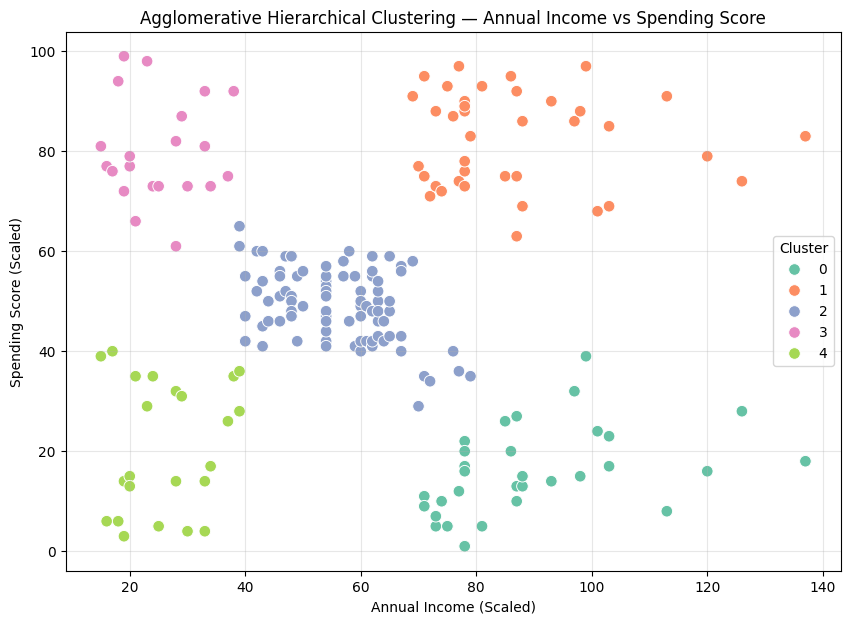

In [20]:
# 4.3 Visualise Hierarchical clusters

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="Hier_Cluster",
    data=df,
    palette="Set2",
    s=70
)

plt.title(
    "Agglomerative Hierarchical Clustering — Annual Income vs Spending Score"
)
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.3)

plt.show()

## 4.3 Visualise Hierarchical Clusters

The Agglomerative Hierarchical Clustering results are visualised using Annual Income and Spending Score.

Each colour represents a different hierarchical cluster.

The scatter plot helps identify how customers are grouped based on their Annual Income and Spending Score and allows comparison with the K-Means clustering results.

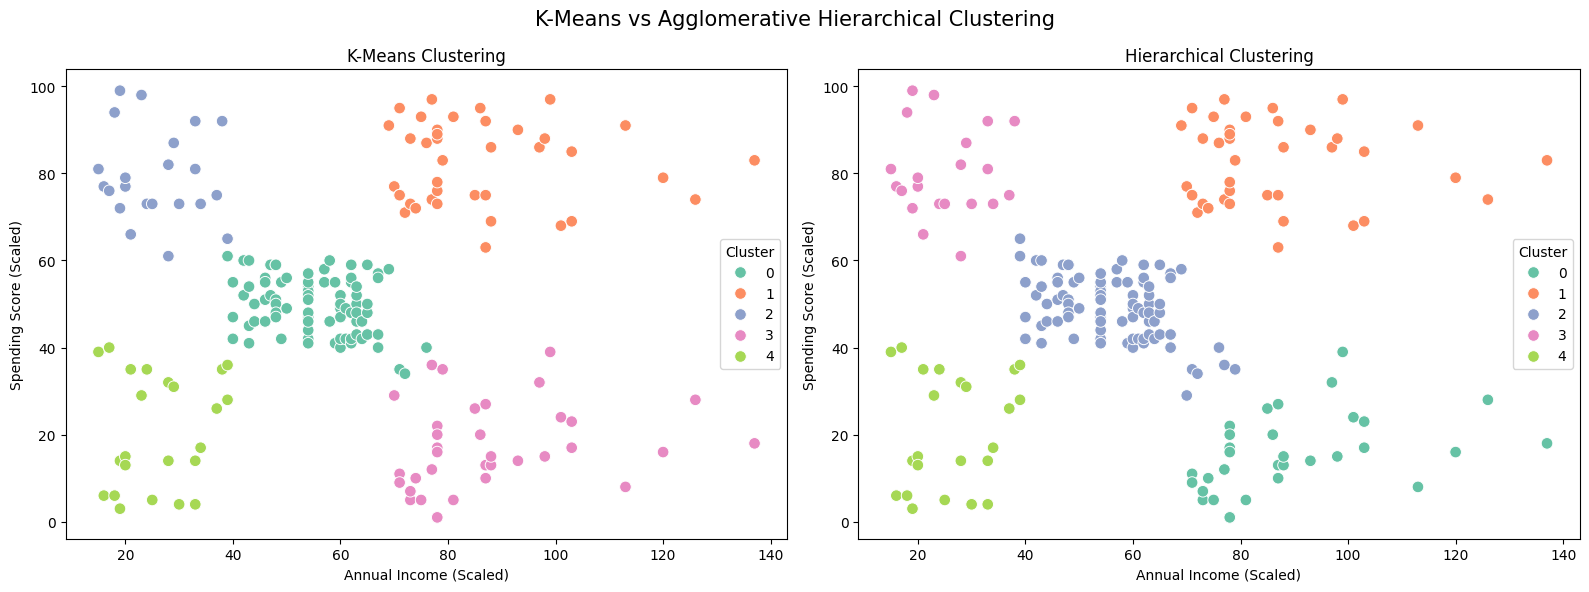

In [21]:
# 4.4 Compare with K-Means

plt.figure(figsize=(16, 6))

# K-Means — Left
plt.subplot(1, 2, 1)

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="KMeans_Cluster",
    data=df,
    palette="Set2",
    s=70
)

plt.title("K-Means Clustering")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend(title="Cluster")

# Hierarchical — Right
plt.subplot(1, 2, 2)

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="Hier_Cluster",
    data=df,
    palette="Set2",
    s=70
)

plt.title("Hierarchical Clustering")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend(title="Cluster")

plt.suptitle(
    "K-Means vs Agglomerative Hierarchical Clustering",
    fontsize=15
)

plt.tight_layout()
plt.show()

## 4.4 Compare K-Means and Hierarchical Clustering

The K-Means and Agglomerative Hierarchical clustering results show broadly similar customer groupings because both methods use Annual Income and Spending Score as the clustering features.

The main cluster boundaries generally agree, especially for customers that are clearly separated into low-income/low-spending, high-income/high-spending, and other distinct regions.

Some border-region customers may be assigned to different clusters by the two algorithms. This happens because the algorithms use different clustering strategies.

K-Means is a centroid-based algorithm. It assigns each customer to the nearest cluster centroid and attempts to minimise the within-cluster sum of squared distances. Its clusters are therefore strongly influenced by the location of the centroids.

Agglomerative Hierarchical Clustering is a connectivity-based approach. It starts with individual observations and progressively merges nearby groups based on their distances. The final clusters depend on the hierarchical structure and the selected linkage method.

Therefore, customers located near cluster boundaries can receive different labels even when the overall segmentation pattern is similar.

Overall, K-Means provides a simple and efficient segmentation based on cluster centroids, while Hierarchical Clustering provides a tree-based view of how customer groups are connected and merged.

In [22]:
# 4.5 Cluster profile table

# Hierarchical clustering profile
hier_profile = df.groupby("Hier_Cluster")[
    ["Age", "Annual_Income", "Spending_Score"]
].mean().round(2)

# Add customer count
hier_profile["Customer_Count"] = (
    df["Hier_Cluster"].value_counts().sort_index()
)

# Display styled table
hier_profile.style \
    .set_caption("Hierarchical Cluster Profile") \
    .format("{:.2f}") \
    .background_gradient(cmap="Reds")

print("K-Means Cluster Profile:")
display(cluster_profile)

print("Hierarchical Cluster Profile:")
display(hier_profile)

K-Means Cluster Profile:


,Age,Annual_Income,Spending_Score,Customer_Count
KMeans_Cluster,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


Hierarchical Cluster Profile:


,Age,Annual_Income,Spending_Score,Customer_Count
Hier_Cluster,,,,
0,41.00,89.41,15.59,32
1,32.69,86.54,82.13,39
2,42.48,55.81,49.13,85
3,25.33,25.10,80.05,21
4,45.22,26.30,20.91,23


## 4.5 Compare Cluster Profiles

The Hierarchical Clustering profile is compared with the K-Means cluster profile using the mean Age, Annual Income, and Spending Score.

The two algorithms should produce broadly similar customer segment definitions because both models use Annual Income and Spending Score for clustering.

The exact cluster numbers may be different because cluster labels are assigned independently by each algorithm. Therefore, Cluster 0 in K-Means does not necessarily correspond to Cluster 0 in Hierarchical Clustering.

To compare the segments, the mean Annual Income and Spending Score should be examined rather than the cluster numbers.

If both methods identify groups such as low-income/low-spending, high-income/high-spending, high-income/low-spending, and low-income/high-spending customers, the segment definitions are considered consistent.

Small differences in the average values and customer assignments are expected, especially for customers located near cluster boundaries.

Overall, consistent segment patterns across both algorithms indicate that the customer segmentation is reasonably stable and meaningful.

# Task 5: DBSCAN Clustering

Objective: Tune DBSCAN parameters and identify density-based customer segments and noise points.

Expected: 4-NN distance plot, parameter comparison table, and DBSCAN scatter plot with noise points.

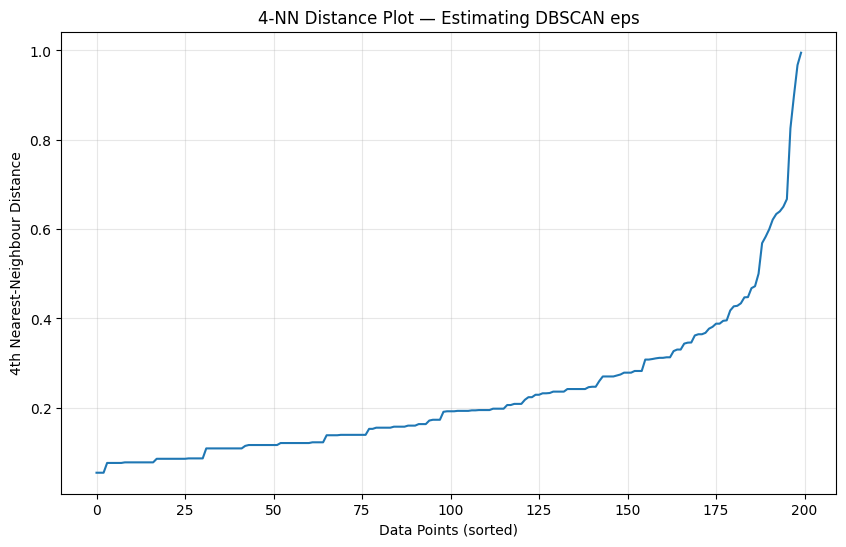

In [23]:
# 5.1 Parameter tuning — epsilon


# Fit 4-Nearest Neighbors
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(df_2f)

# Calculate distances to the 4th nearest neighbour
distances, indices = neighbors_fit.kneighbors(df_2f)

# Take the 4th-nearest-neighbour distance for each point
k_distances = distances[:, 3]

# Sort distances
k_distances = np.sort(k_distances)

# Plot 4-NN distance graph
plt.figure(figsize=(10, 6))

plt.plot(k_distances)

plt.title("4-NN Distance Plot — Estimating DBSCAN eps")
plt.xlabel("Data Points (sorted)")
plt.ylabel("4th Nearest-Neighbour Distance")
plt.grid(True, alpha=0.3)

plt.show()

In [24]:
# 5.2 Grid search eps & min_samples


eps_values = [0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [3, 4, 5, 6]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(df_2f)

        # Number of clusters excluding noise (-1)
        unique_labels = set(labels)
        n_clusters = len(unique_labels - {-1})

        # Number of noise points
        n_noise = np.sum(labels == -1)

        # Silhouette score excluding noise
        non_noise_mask = labels != -1

        if (
            n_clusters >= 2
            and np.sum(non_noise_mask) > n_clusters
        ):
            silhouette = silhouette_score(
                df_2f[non_noise_mask],
                labels[non_noise_mask]
            )
        else:
            silhouette = np.nan

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette_score": silhouette
        })

# Create results DataFrame
dbscan_results = pd.DataFrame(results)

# Sort by silhouette score
dbscan_results = dbscan_results.sort_values(
    by="silhouette_score",
    ascending=False
)

display(dbscan_results.round(4))

print("Top DBSCAN parameter combinations:")
display(dbscan_results.head(10).round(4))

,eps,min_samples,n_clusters,n_noise,silhouette_score
1,0.2,4,5,73,0.6173
3,0.2,6,4,95,0.6138
2,0.2,5,7,77,0.5856
7,0.3,6,6,48,0.5302
6,0.3,5,7,35,0.5243
5,0.3,4,8,23,0.5197
11,0.4,6,4,19,0.4900
10,0.4,5,4,15,0.4781
4,0.3,3,9,14,0.4720
0,0.2,3,13,44,0.4697


Top DBSCAN parameter combinations:


,eps,min_samples,n_clusters,n_noise,silhouette_score
1,0.2,4,5,73,0.6173
3,0.2,6,4,95,0.6138
2,0.2,5,7,77,0.5856
7,0.3,6,6,48,0.5302
6,0.3,5,7,35,0.5243
5,0.3,4,8,23,0.5197
11,0.4,6,4,19,0.4900
10,0.4,5,4,15,0.4781
4,0.3,3,9,14,0.4720
0,0.2,3,13,44,0.4697


In [25]:
# 5.3 Fit final DBSCAN model


# Selected parameters from Task 5.2
best_eps = 0.5
best_min_samples = 4

# Fit final DBSCAN model
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

# Predict cluster labels
df["DBSCAN_Cluster"] = dbscan.fit_predict(df_2f)

# Display results
display(df.head())

# Check cluster counts
print("DBSCAN Cluster Counts:")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

,Gender,Age,Annual_Income,Spending_Score,KMeans_Cluster,Hier_Cluster,DBSCAN_Cluster
0,1,19,15,39,4,4,0
1,1,21,15,81,2,3,0
2,0,20,16,6,4,4,0
3,0,23,16,77,2,3,0
4,0,31,17,40,4,4,0


DBSCAN Cluster Counts:
DBSCAN_Cluster
-1      8
 0    157
 1     35
Name: count, dtype: int64


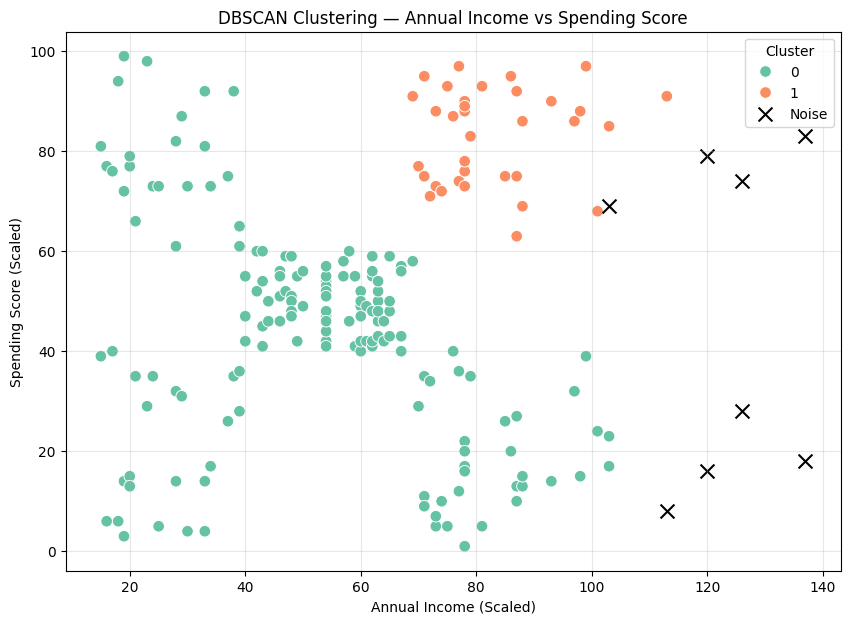

In [26]:
# 5.4 Visualise DBSCAN clusters

plt.figure(figsize=(10, 7))

# Non-noise points
non_noise = df[df["DBSCAN_Cluster"] != -1]

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="DBSCAN_Cluster",
    data=non_noise,
    palette="Set2",
    s=70
)

# Noise points
noise = df[df["DBSCAN_Cluster"] == -1]

plt.scatter(
    noise["Annual_Income"],
    noise["Spending_Score"],
    c="black",
    marker="x",
    s=100,
    label="Noise"
)

plt.title("DBSCAN Clustering — Annual Income vs Spending Score")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.3)

plt.show()

## 5.4 Visualise DBSCAN Clusters

DBSCAN uses two important parameters: eps and min_samples.

The eps parameter defines the maximum distance between two points for them to be considered neighbours.

The min_samples parameter defines the minimum number of nearby points required for a point to be considered part of a dense region.

DBSCAN identifies clusters based on data density rather than cluster centroids.

Points that do not have enough nearby points within the eps distance are classified as noise and receive the label -1.

In the scatter plot, noise points are shown as black X markers. These points are too far from sufficiently dense regions to belong to a cluster.

This makes DBSCAN useful for identifying both customer groups and unusual or isolated customer observations.



## 5.5 DBSCAN vs K-Means — Shape Detection

DBSCAN and K-Means use different approaches for identifying customer segments.

1. DBSCAN does not require specifying the number of clusters (k) in advance. It automatically identifies the number of clusters based on the density of the data.

2. DBSCAN can detect arbitrarily shaped clusters, while K-Means generally works best when clusters are approximately spherical or centroid-based.

3. DBSCAN can label low-density or isolated points as noise using the label -1. K-Means does not identify noise and forces every customer into one of the specified clusters.

4. In this dataset, the three clustering algorithms do not necessarily agree exactly on the number of customer segments. K-Means and Hierarchical Clustering are expected to produce a similar overall segmentation, while DBSCAN may identify a different number of dense groups and may classify some customers as noise.

5. The most stable segments across the three methods are the clearly separated customer groups, particularly customers with low income and low spending and customers with high income and high spending. These groups are located in dense and visually distinct regions, so they are more consistently identified by different clustering methods.

Overall, K-Means provides centroid-based segmentation, Hierarchical Clustering shows the hierarchical relationships between customers, and DBSCAN identifies dense regions and potential outliers. Comparing all three methods provides a more reliable understanding of customer segments.

# Task 6: Algorithm Comparison & Business Insights

Objective: Compare K-Means, Hierarchical, and DBSCAN clustering results and derive business recommendations.

Expected: Three-panel comparison figure, metrics summary table, and structured business insights.

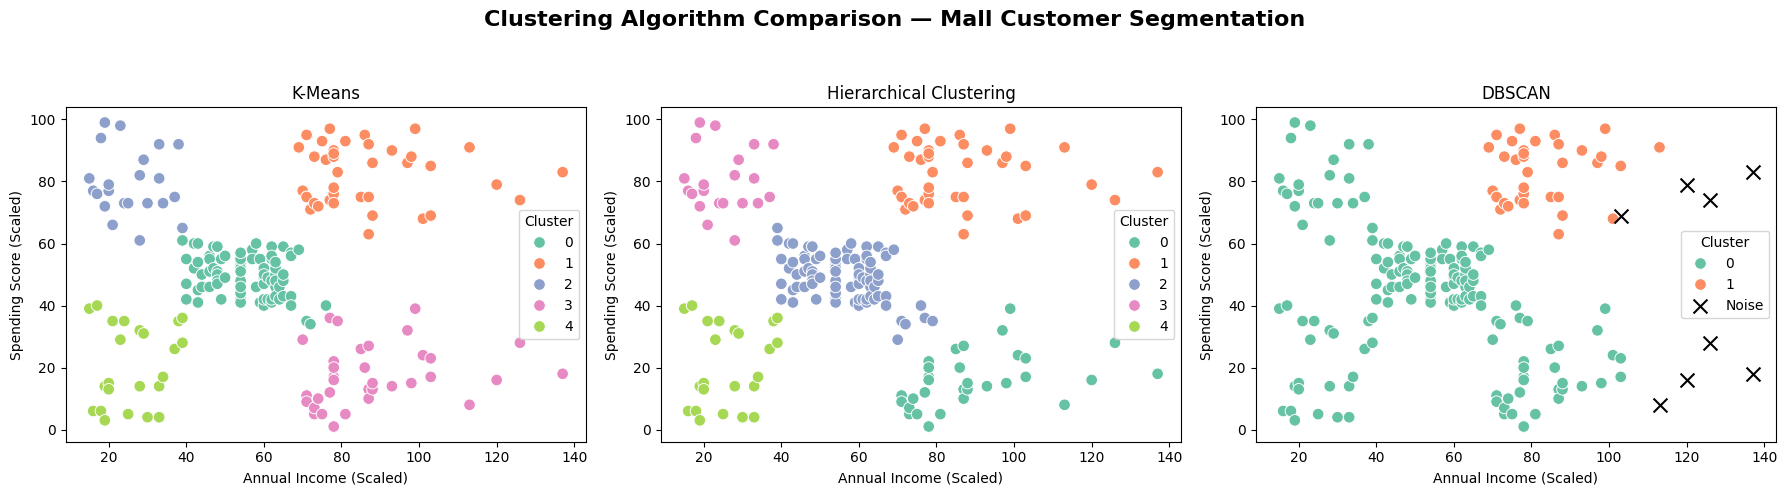

In [27]:
# 6.1 Three-panel comparison figure

plt.figure(figsize=(18, 5))

# Panel 1 — K-Means
plt.subplot(1, 3, 1)

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="KMeans_Cluster",
    data=df,
    palette="Set2",
    s=70
)

plt.title("K-Means")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend(title="Cluster")


# Panel 2 — Hierarchical
plt.subplot(1, 3, 2)

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="Hier_Cluster",
    data=df,
    palette="Set2",
    s=70
)

plt.title("Hierarchical Clustering")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend(title="Cluster")


# Panel 3 — DBSCAN
plt.subplot(1, 3, 3)

# Non-noise points
non_noise = df[df["DBSCAN_Cluster"] != -1]

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="DBSCAN_Cluster",
    data=non_noise,
    palette="Set2",
    s=70
)

# Noise points
noise = df[df["DBSCAN_Cluster"] == -1]

plt.scatter(
    noise["Annual_Income"],
    noise["Spending_Score"],
    c="black",
    marker="x",
    s=100,
    label="Noise"
)

plt.title("DBSCAN")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend(title="Cluster")


# Overall title
plt.suptitle(
    "Clustering Algorithm Comparison — Mall Customer Segmentation",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 6.1 Three-Panel Clustering Comparison

The three-panel figure compares K-Means, Agglomerative Hierarchical Clustering, and DBSCAN using Annual Income and Spending Score.

All three algorithms are plotted on the same two feature axes so that their customer segmentation patterns can be visually compared.

K-Means forms clusters around centroids, Hierarchical Clustering groups customers based on hierarchical distance relationships, and DBSCAN identifies dense regions while also detecting noise points.

Using the same feature space and consistent colour logic makes it easier to identify similarities and differences between the three clustering approaches.

In [28]:
# 6.2 Metrics summary table

# K-Means
kmeans_silhouette = silhouette_score(
    df_2f,
    df["KMeans_Cluster"]
)

kmeans_clusters = df["KMeans_Cluster"].nunique()


# Hierarchical Clustering
hier_silhouette = silhouette_score(
    df_2f,
    df["Hier_Cluster"]
)

hier_clusters = df["Hier_Cluster"].nunique()


# DBSCAN — exclude noise points (-1)
dbscan_labels = df["DBSCAN_Cluster"]

non_noise_mask = dbscan_labels != -1
dbscan_non_noise_data = df_2f[non_noise_mask]
dbscan_non_noise_labels = dbscan_labels[non_noise_mask]

dbscan_clusters = len(
    set(dbscan_non_noise_labels)
)

if dbscan_clusters >= 2:
    dbscan_silhouette = silhouette_score(
        dbscan_non_noise_data,
        dbscan_non_noise_labels
    )
else:
    dbscan_silhouette = np.nan


# Create metrics summary table
metrics_summary = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "n_clusters": [
        kmeans_clusters,
        hier_clusters,
        dbscan_clusters
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        hier_silhouette,
        dbscan_silhouette
    ]
})

metrics_summary["Silhouette Score"] = (
    metrics_summary["Silhouette Score"].round(4)
)

display(metrics_summary)


# Find the best algorithm automatically:

best_algorithm = metrics_summary.loc[
    metrics_summary["Silhouette Score"].idxmax(),
    "Algorithm"
]

best_score = metrics_summary["Silhouette Score"].max()

print("Best Algorithm:", best_algorithm)
print("Highest Silhouette Score:", round(best_score, 4))

,Algorithm,n_clusters,Silhouette Score
0,K-Means,5,0.5547
1,Hierarchical,5,0.5538
2,DBSCAN,2,0.3876


Best Algorithm: K-Means
Highest Silhouette Score: 0.5547


## 6.2 Metrics Summary and Best Algorithm

The clustering algorithms are compared using the number of clusters and the Silhouette Score.

For DBSCAN, noise points with the label -1 are excluded from the Silhouette Score calculation because they do not belong to any cluster.

The Silhouette Score measures both cluster compactness and separation. A higher score indicates that customers are more similar to the other customers within their own cluster and more different from customers in neighbouring clusters.

The algorithm with the highest Silhouette Score is considered the best-performing algorithm for this dataset based on clustering quality.

Therefore, the algorithm with the highest Silhouette Score provides the most compact and well-separated customer segments among the three tested methods.

The number of clusters is also considered when interpreting the results, because a high Silhouette Score alone should not be used without checking whether the resulting segments are meaningful from a business perspective.

# 6.3 Business insight report (Markdown)


K-Means clustering is used as the main model for business interpretation because its customer segments are easy to understand and communicate to mall management.

The customer segments are interpreted using their average Annual Income and Spending Score.

## Segment 1 — Low Income / Low Spending

These customers have relatively low annual income and low spending scores.

Business Insight:
They are price-sensitive customers and may respond better to affordable products and value-based offers.

Recommended Marketing Action:
Offer budget promotions, discount coupons, seasonal sales, and value-for-money product offers to encourage more purchases.

---

## Segment 2 — High Income / Low Spending

These customers have relatively high annual income but low spending scores.

Business Insight:
They have strong purchasing capacity but are not currently spending heavily at the mall.

Recommended Marketing Action:
Use personalised premium offers, targeted product recommendations, and exclusive shopping benefits to increase their engagement and spending.

---

## Segment 3 — Low Income / High Spending

These customers have relatively low annual income but high spending scores.

Business Insight:
They are highly engaged shoppers despite having lower income.

Recommended Marketing Action:
Provide loyalty rewards, frequent-buyer discounts, and attractive value deals to retain these customers and encourage repeat visits.

---

## Segment 4 — High Income / High Spending

These customers have both high annual income and high spending scores.

Business Insight:
They represent a valuable customer segment with strong purchasing power and high engagement.

Recommended Marketing Action:
Target them with VIP memberships, premium brands, exclusive events, personalised offers, and high-value loyalty rewards.

---

## Segment 5 — Moderate Income / Moderate Spending

These customers have moderate income and moderate spending behaviour.

Business Insight:
They represent a potential growth segment that can be encouraged to increase their shopping frequency and spending.

Recommended Marketing Action:
Use personalised promotions, seasonal campaigns, cross-selling offers, and loyalty incentives to gradually move them toward higher spending.

---

## Recommended Algorithm for Deployment

K-Means is recommended as the primary algorithm for deployment because it provides simple and highly interpretable customer segments.

The clusters can be easily explained to management using business categories such as Low Income/Low Spending, High Income/High Spending, and High Income/Low Spending.

K-Means is also computationally efficient and makes it straightforward to assign customers to segments based on their distance from cluster centroids.

DBSCAN would be preferable when the shape of the clusters is unknown or when identifying noise and unusual customers is especially important.

Hierarchical Clustering would be preferable when management needs a dendrogram showing the hierarchy and relationships between customer groups.

For this Mall Customer Segmentation project, K-Means provides the best balance of interpretability, simplicity, and business usability.

## Overall Business Recommendation

Mall management should use the K-Means customer segments to create targeted marketing campaigns instead of using the same promotion for every customer.

High Income/High Spending customers should receive premium and VIP benefits, while Low Income/High Spending customers should receive loyalty and value-based rewards. High Income/Low Spending customers should receive personalised incentives to increase engagement, and Low Income/Low Spending customers should be targeted with budget-friendly promotions.

This segmentation-based marketing strategy can help the mall improve customer engagement, increase repeat purchases, and allocate marketing resources more effectively.

Note: The exact K-Means cluster numbers should be interpreted using the cluster profile table because cluster labels are assigned automatically by the algorithm.

In [29]:
import joblib

joblib.dump(kmeans, "customer_segmentation_model.pkl")

print("Customer segmentation model saved successfully.")

Customer segmentation model saved successfully.


In [31]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

# Mall Customer features
features = df[["Age", "Annual_Income", "Spending_Score"]]

scaler.fit(features)

joblib.dump(scaler, "rfm_scaler.pkl")

print("RFM scaler saved successfully.")

RFM scaler saved successfully.
